In [5]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
from sklearn.preprocessing import StandardScaler
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import itertools
import os
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [6]:
df = gpd.read_file('../data/updated_data.geojson')

In [7]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

# selected_covariates = ['fem_house_rate', 'fertility_rate', 'GDP', 'young_neet', 'internet_coverage_rate', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']
selected_covariates = ['private_coverage', 'fem_maj_empl_rate', 'public_coverage', 'service_empl_rate', 'graduate_mobility_rate', 'empl_growth']

X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

N = 107 
P = len(selected_covariates) 

In [8]:
std_y = np.std(y_star)
median_y = np.median(y_star)

In [9]:
df = df.reset_index(drop=True)

n = len(df)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = df.sindex  # spatial index

for i, geom in enumerate(df.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(df.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1

In [10]:
model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> C;
  array[N] int<lower=1, upper=C> cluster;  
  real std_y;
  real median_y;        
  vector[N] y_star;             
  matrix[N, P] X_star;           
  matrix<lower=0, upper=1>[N, N] W;  
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {           
  real alpha;  
  vector[P] b0;
  vector<lower = 1e-6, upper=100>[P] lambda_b;      
  matrix[P, C] beta; 
  vector<lower=1e-6>[C] tau;  
  real<lower=1e-6> tau2;                  // CAR precision
  vector[N] phi_raw;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}

transformed parameters {
  vector[N] phi;
  phi = phi_raw - mean(phi_raw);

  vector<lower=0>[C] sigma = inv_sqrt(tau); 

  vector<lower=0>[P] sd_beta = std_y * sqrt(lambda_b); 
}


model {
  // Priors
  for (j in 1:P) {
    b0[j] ~ normal(0, 1);
    lambda_b[j] ~ gamma(0.5, 0.5);
  }

  for(k in 1:C) {
    tau[k] ~ gamma(2, 1);
  }

  alpha ~ normal(0, 1);

  for (j in 1:P) {
    for (k in 1:C) {
      beta[j, k] ~ normal(0, 1);
    }
  }


  // CAR prior
  tau2  ~ gamma(2, 1);
  rho   ~ beta(1, 1);
  phi_raw ~ car_leroux(tau2, rho, W, D, lambda, N);

  // Likelihood
  for (i in 1:N) {

    int c = cluster[i];
    real mu = alpha + dot_product(row(X_star, i), beta[, c]) + phi[i];
    target += normal_lpdf(y_star[i] | mu, sigma[c]);
  }
}

"""

In [11]:
with open("final_model_nomix.stan", "w") as f:
    f.write(model)

In [12]:
# save labels from file
with open("labels.txt", "r") as f:
    cluster_labels = [int(line.strip()) for line in f.readlines()]

In [13]:
df["cluster"] = cluster_labels
C = len(set(cluster_labels))

In [14]:
data_m = {
    "N": int(N),
    "P": int(P),
    "C": C,
    "cluster": df["cluster"].astype(int),
    "std_y": float(std_y),
    "median_y": float(median_y),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "W": W,
}

In [15]:
model_exe = CmdStanModel(stan_file="final_model_nomix.stan")

14:42:58 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\final_model_nomix.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\final_model_nomix.exe
14:45:58 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\final_model_nomix.exe


In [16]:
fit_l = model_exe.sample(
    data=data_m,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.99,
    max_treedepth=15,
)

14:45:59 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

14:46:10 - cmdstanpy - INFO - CmdStan done processing.


In [17]:
fit_l.diagnose()

'Checking sampler transitions treedepth.\nTreedepth satisfactory for all transitions.\n\nChecking sampler transitions for divergences.\nNo divergent transitions found.\n\nChecking E-BFMI - sampler transitions HMC potential energy.\nE-BFMI satisfactory.\n\nRank-normalized split effective sample size satisfactory for all parameters.\n\nRank-normalized split R-hat values satisfactory for all parameters.\n\nProcessing complete, no problems detected.\n'

In [18]:
fit_l.column_names

('lp__',
 'accept_stat__',
 'stepsize__',
 'treedepth__',
 'n_leapfrog__',
 'divergent__',
 'energy__',
 'alpha',
 'b0[1]',
 'b0[2]',
 'b0[3]',
 'b0[4]',
 'b0[5]',
 'b0[6]',
 'lambda_b[1]',
 'lambda_b[2]',
 'lambda_b[3]',
 'lambda_b[4]',
 'lambda_b[5]',
 'lambda_b[6]',
 'beta[1,1]',
 'beta[2,1]',
 'beta[3,1]',
 'beta[4,1]',
 'beta[5,1]',
 'beta[6,1]',
 'tau[1]',
 'tau2',
 'phi_raw[1]',
 'phi_raw[2]',
 'phi_raw[3]',
 'phi_raw[4]',
 'phi_raw[5]',
 'phi_raw[6]',
 'phi_raw[7]',
 'phi_raw[8]',
 'phi_raw[9]',
 'phi_raw[10]',
 'phi_raw[11]',
 'phi_raw[12]',
 'phi_raw[13]',
 'phi_raw[14]',
 'phi_raw[15]',
 'phi_raw[16]',
 'phi_raw[17]',
 'phi_raw[18]',
 'phi_raw[19]',
 'phi_raw[20]',
 'phi_raw[21]',
 'phi_raw[22]',
 'phi_raw[23]',
 'phi_raw[24]',
 'phi_raw[25]',
 'phi_raw[26]',
 'phi_raw[27]',
 'phi_raw[28]',
 'phi_raw[29]',
 'phi_raw[30]',
 'phi_raw[31]',
 'phi_raw[32]',
 'phi_raw[33]',
 'phi_raw[34]',
 'phi_raw[35]',
 'phi_raw[36]',
 'phi_raw[37]',
 'phi_raw[38]',
 'phi_raw[39]',
 'phi_raw[4

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha       0.053  0.021   0.011    0.091      0.000    0.000    6696.0   
beta[0, 0]  0.103  0.037   0.033    0.170      0.001    0.000    1508.0   
beta[1, 0] -0.079  0.031  -0.136   -0.020      0.001    0.000    1792.0   
beta[2, 0]  0.149  0.034   0.084    0.211      0.001    0.000    1688.0   
beta[3, 0] -0.058  0.030  -0.111   -0.000      0.001    0.000    2661.0   
...           ...    ...     ...      ...        ...      ...       ...   
phi[103]    0.117  0.125  -0.115    0.351      0.002    0.001    5026.0   
phi[104]   -0.172  0.183  -0.520    0.161      0.004    0.002    1847.0   
phi[105]   -0.064  0.168  -0.389    0.251      0.004    0.002    1590.0   
phi[106]   -0.038  0.139  -0.292    0.226      0.002    0.001    3561.0   
rho         0.798  0.120   0.577    0.950      0.004    0.002     760.0   

            ess_tail  r_hat  
alpha         5225.0   1.00  
beta[0, 0]    3277.0   1.00  
beta[1, 0

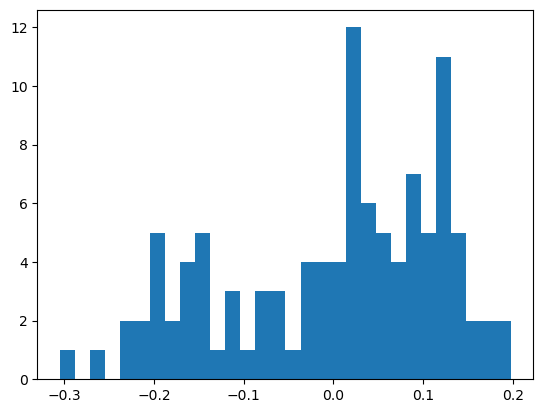

In [19]:
summary_95 = az.summary(fit_l, var_names=["alpha", "beta", "phi", "rho"])
print(summary_95)
phi_mean = summary_95.loc[summary_95.index.str.startswith("phi"), "mean"].values
plt.hist(phi_mean, bins=30)

betas_mean = summary_95.loc[summary_95.index.str.startswith("beta"), "mean"].values

In [20]:
betas_mean

array([ 0.103, -0.079,  0.149, -0.058,  0.253,  0.05 ])

In [21]:
summary_alpha_beta = az.summary(fit_l, var_names=["alpha", "beta"])
summary_alpha_beta = pd.DataFrame(summary_alpha_beta)
print(summary_alpha_beta)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha       0.053  0.021   0.011    0.091      0.000    0.000    6696.0   
beta[0, 0]  0.103  0.037   0.033    0.170      0.001    0.000    1508.0   
beta[1, 0] -0.079  0.031  -0.136   -0.020      0.001    0.000    1792.0   
beta[2, 0]  0.149  0.034   0.084    0.211      0.001    0.000    1688.0   
beta[3, 0] -0.058  0.030  -0.111   -0.000      0.001    0.000    2661.0   
beta[4, 0]  0.253  0.045   0.162    0.331      0.002    0.001     898.0   
beta[5, 0]  0.050  0.026  -0.002    0.097      0.000    0.000    4081.0   

            ess_tail  r_hat  
alpha         5225.0   1.00  
beta[0, 0]    3277.0   1.00  
beta[1, 0]    3993.0   1.00  
beta[2, 0]    3560.0   1.00  
beta[3, 0]    4465.0   1.00  
beta[4, 0]    2085.0   1.01  
beta[5, 0]    4547.0   1.00  


In [22]:
import arviz as az
import pandas as pd
import numpy as np
import re

# ArviZ summary (keeps mean, sd, r_hat, etc.)
summ = pd.DataFrame(az.summary(fit_l, var_names=["alpha", "beta"]))

# Posterior draws (as numpy arrays)
alpha = fit_l.stan_variable("alpha")  # (draws,) or (draws, ...)
beta  = fit_l.stan_variable("beta")   # (draws, K) or (draws, ...)

def _parse_indices(label: str):
    """Extract indices from 'beta[0]' or 'beta[0,1]' -> (0,) or (0,1)."""
    m = re.search(r"\[(.*)\]", label)
    if not m:
        return ()
    return tuple(int(x.strip()) for x in m.group(1).split(","))

def _get_samples(label: str):
    """Return the posterior samples matching the row label from az.summary()."""
    base = label.split("[", 1)[0]

    if base == "alpha":
        idx = _parse_indices(label)
        arr = alpha
        return arr[(slice(None),) + idx] if idx else arr

    if base == "beta":
        idx = _parse_indices(label)
        arr = beta
        return arr[(slice(None),) + idx] if idx else arr

    return None

# Add quantiles using the SAME index as summ
q5, q50, q95 = [], [], []
for row_label in summ.index.astype(str):
    samples = _get_samples(row_label)
    if samples is None:
        q5.append(np.nan); q50.append(np.nan); q95.append(np.nan)
    else:
        qs = np.percentile(samples, [5, 50, 95])
        q5.append(qs[0]); q50.append(qs[1]); q95.append(qs[2])

summ["q5"]  = q5
summ["q50"] = q50
summ["q95"] = q95

# Show what you want (ArviZ uses "sd" not "std")
cols = [c for c in ["mean", "sd", "r_hat", "q5", "q50", "q95"] if c in summ.columns]
print(summ[cols])


             mean     sd  r_hat        q5       q50       q95
alpha       0.053  0.021   1.00  0.018189  0.052919  0.087554
beta[0, 0]  0.103  0.037   1.00  0.042675  0.102795  0.163429
beta[1, 0] -0.079  0.031   1.00 -0.130871 -0.079316 -0.027500
beta[2, 0]  0.149  0.034   1.00  0.093402  0.149273  0.205478
beta[3, 0] -0.058  0.030   1.00 -0.106442 -0.058351 -0.008656
beta[4, 0]  0.253  0.045   1.01  0.176510  0.253460  0.325923
beta[5, 0]  0.050  0.026   1.00  0.006062  0.049935  0.091875


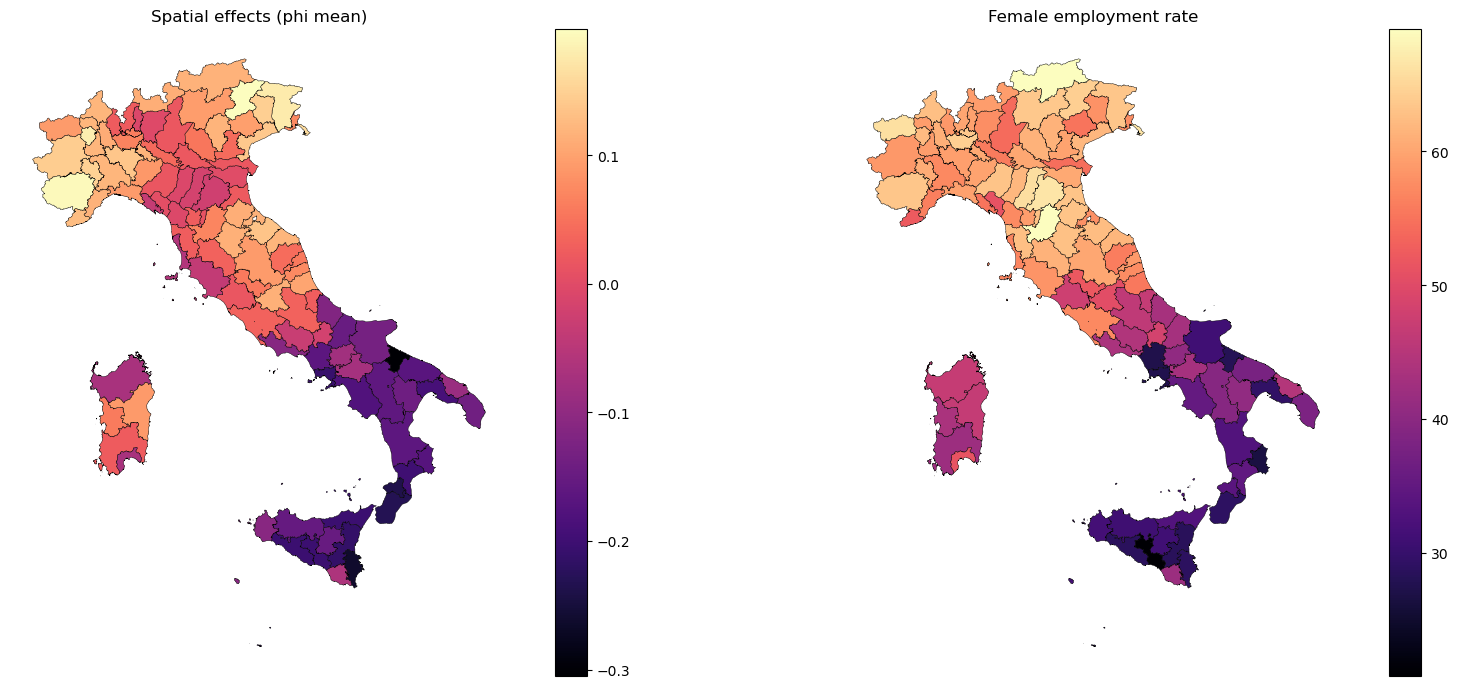

In [23]:
import geopandas as gpd

# gdf: GeoDataFrame with one row per observation/region
# must have a geometry column of polygons/multipolygons
gdf = gpd.read_file("../data/updated_data.geojson")
gdf["phi_mean"] = phi_mean

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

gdf.plot(column="phi_mean", categorical=False, legend=True, ax=ax1, cmap="magma", edgecolor="black", linewidth=0.3)
ax1.set_title("Spatial effects (phi mean)")
ax1.set_axis_off()

gdf.plot(column="fem_empl_rate", categorical=False, legend=True, ax=ax2, cmap="magma", edgecolor="black", linewidth=0.3)
ax2.set_title("Female employment rate")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

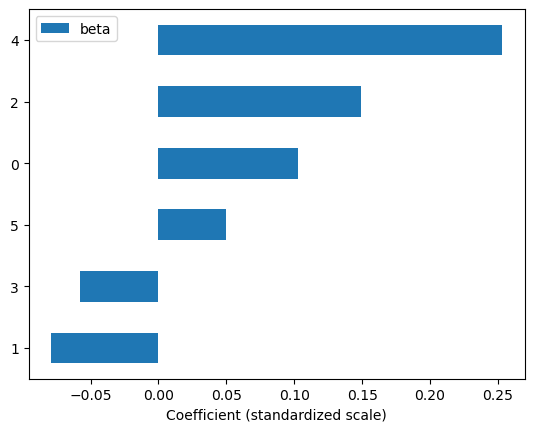

In [24]:
plt.figure(figsize=(8,6))
pd.DataFrame(betas_mean, columns=['beta']).sort_values(by='beta').plot(kind='barh')
plt.xlabel('Coefficient (standardized scale)')
plt.show()

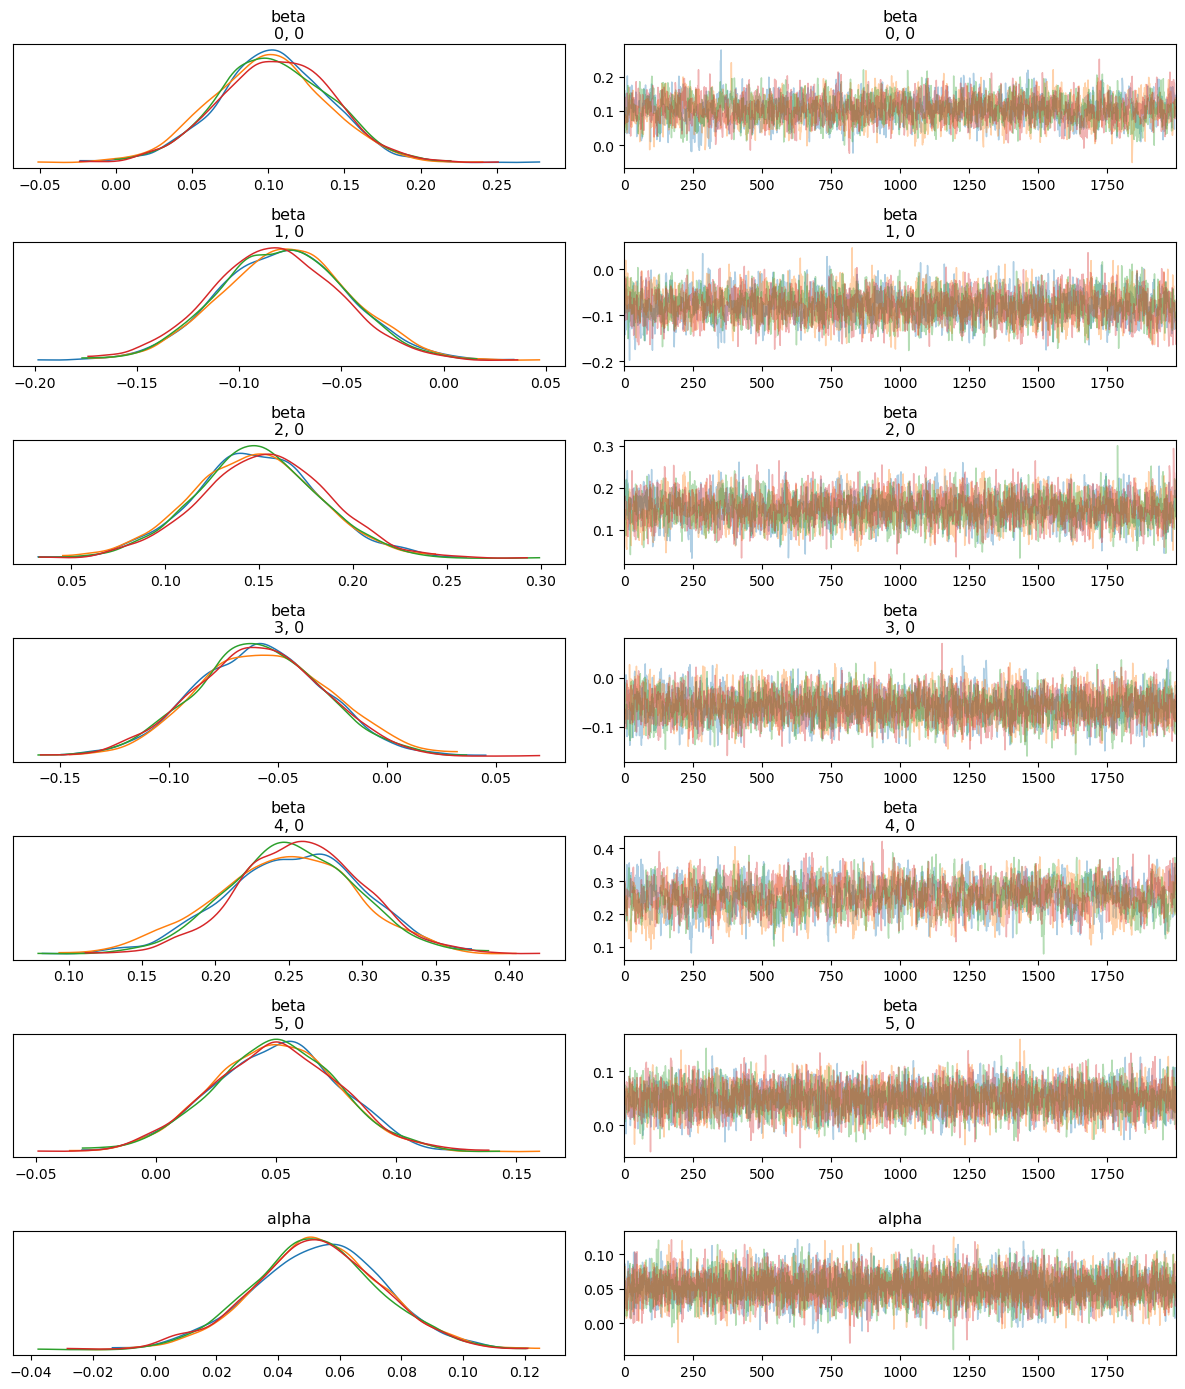

In [25]:
az.rcParams["plot.max_subplots"] = 100   
az.plot_trace(fit_l, var_names=["beta", "alpha"], compact=False)
plt.tight_layout()

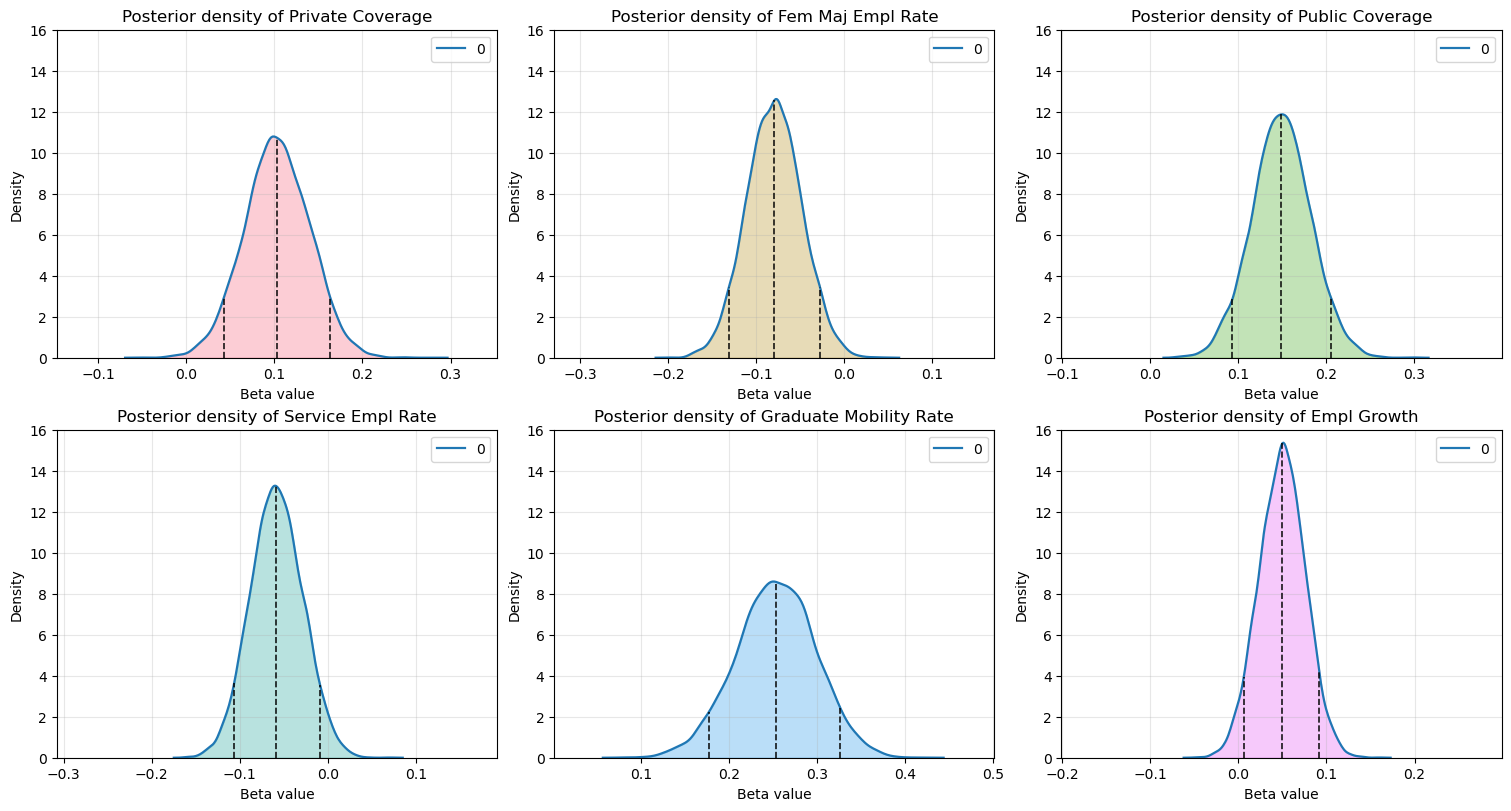

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

posterior_betas = fit_l.stan_variable("beta")  # (draws, 6)
num_betas = posterior_betas.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes = axes.ravel()

colors = sns.color_palette("husl", n_colors=num_betas)

YMAX = 16
XWIDTH = 0.5  # fixed x-span (xmax - xmin)

for i in range(num_betas):
    ax = axes[i]
    samples = posterior_betas[:, i]

    # Draw KDE line (reliable access to x/y)
    sns.kdeplot(samples, ax=ax, color=colors[i], linewidth=1.6, fill=False)
    kde_line = ax.lines[-1]
    xs = kde_line.get_xdata()
    ys = kde_line.get_ydata()

    # Fill under the curve
    ax.fill_between(xs, 0, ys, alpha=0.35, color=colors[i])

    ax.set_title(f"Posterior density of " + selected_covariates[i].replace("_", " ").title())
    ax.set_xlabel("Beta value")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)

    # Fixed y-axis for comparability
    ax.set_ylim(0, YMAX)

    # Quantiles + lines that reach the KDE curve
    qs = np.percentile(samples, [5, 50, 95])
    y_at_q = np.interp(qs, xs, ys)
    ax.vlines(qs, ymin=0, ymax=y_at_q, colors="black",
              linestyles="--", linewidth=1.2, alpha=0.9)

    # Fixed x-axis width (0.5), centered on midpoint of [q5, q95]
    center = 0.5 * (qs[0] + qs[2])
    ax.set_xlim(center - XWIDTH / 2, center + XWIDTH / 2)

# (safe) turn off any unused axes
for j in range(num_betas, len(axes)):
    axes[j].axis("off")

fig.savefig("posterior_betas_kde_3x2.png", dpi=300, bbox_inches="tight")
fig.savefig("posterior_betas_kde_3x2.pdf", bbox_inches="tight")
plt.show()


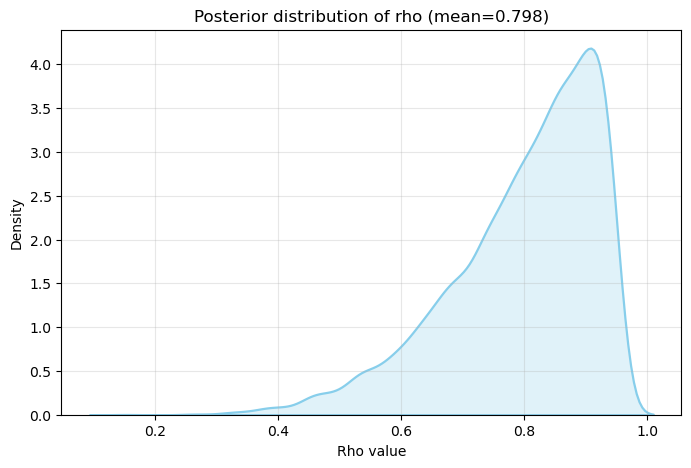

Posterior mean of rho: 0.798


In [27]:
# print posterior mean of rho and plot posterior distribution of rho
rho_samples = fit_l.stan_variable("rho")
rho_mean = np.mean(rho_samples)
plt.figure(figsize=(8, 5))
sns.kdeplot(rho_samples, fill=True, color="skyblue", linewidth=1.6)
plt.title(f"Posterior distribution of rho (mean={rho_mean:.3f})")
plt.xlabel("Rho value")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)

plt.show()
print(f"Posterior mean of rho: {rho_mean:.3f}")